In [1]:
# Used Car Price Prediction (Linear Regression)
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# 2. Load Dataset
df = pd.read_csv("used_car_price_prediction.csv")

df.head()

,Year,KM_Driven,Fuel_Type,Owner_Count,Mileage,Price
0,2019,92851,CNG,1,12.513284,630357.316657
1,2019,136232,CNG,2,23.770667,323644.905606
2,2014,139955,CNG,3,23.557733,345867.295416
3,2021,68250,Petrol,3,14.322857,351401.757154
4,2009,147969,Petrol,1,17.042746,592998.777029


In [4]:
# 3. Explore Dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         100 non-null    int64  
 1   KM_Driven    100 non-null    int64  
 2   Fuel_Type    100 non-null    object 
 3   Owner_Count  100 non-null    int64  
 4   Mileage      100 non-null    float64
 5   Price        100 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 4.8+ KB


,Year,KM_Driven,Owner_Count,Mileage,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000
mean,2015.080000,75922.89000,1.970000,18.680664,589599.649449
std,4.560879,42971.76541,0.846323,3.868377,202310.163958
min,2008.000000,5503.00000,1.000000,12.063215,226070.774913
25%,2011.000000,36544.25000,1.000000,15.434399,408386.346869
50%,2014.000000,75779.50000,2.000000,18.234341,615083.776923
75%,2019.000000,110431.75000,3.000000,22.671269,770935.109288
max,2023.000000,148942.00000,3.000000,24.984275,879245.226542


In [5]:
# 4. Check Missing Values
df.isnull().sum()

Year           0
KM_Driven      0
Fuel_Type      0
Owner_Count    0
Mileage        0
Price          0
dtype: int64

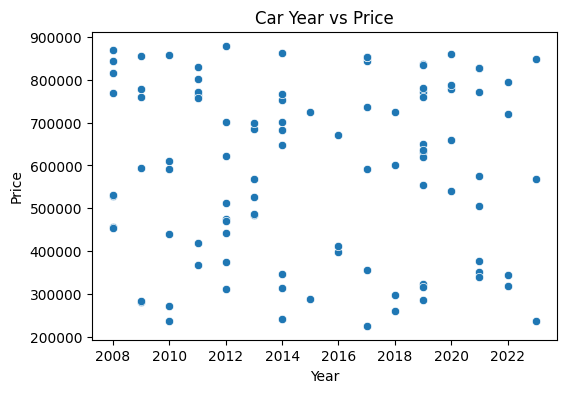

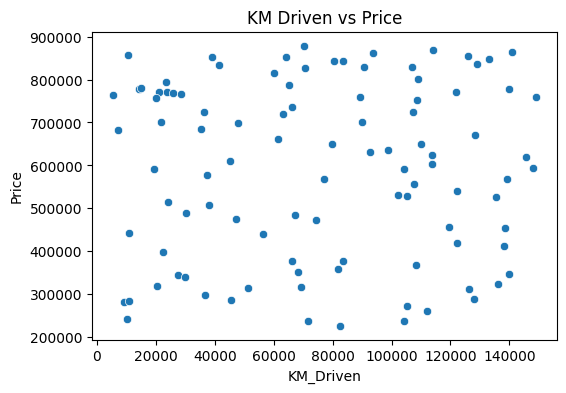

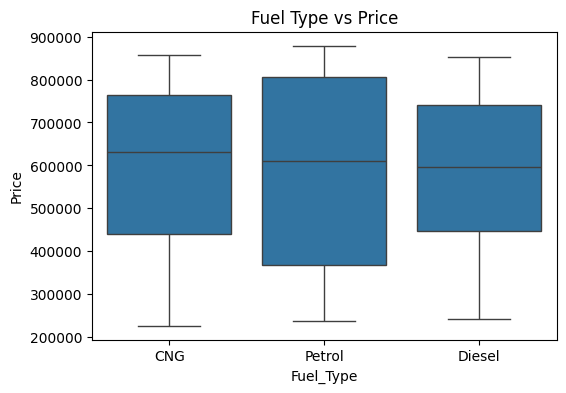

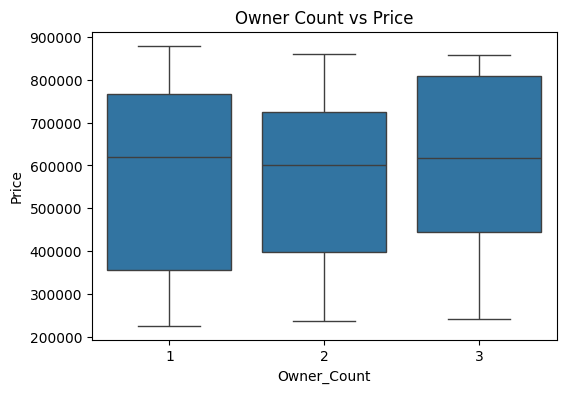

In [9]:
# 5. Visualize Price Trends
# Year vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='Year', y='Price', data=df)
plt.title("Car Year vs Price")
plt.show()

# KM Driven vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='KM_Driven', y='Price', data=df)
plt.title("KM Driven vs Price")
plt.show()

# Fuel Type vs Price
plt.figure(figsize=(6,4))
sns.boxplot(x='Fuel_Type', y='Price', data=df)
plt.title("Fuel Type vs Price")
plt.show()

# Owner Count vs Price
plt.figure(figsize=(6,4))
sns.boxplot(x='Owner_Count', y='Price', data=df)
plt.title("Owner Count vs Price")
plt.show()

In [10]:
# 6. Encode Categorical Variable
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

# Example mapping:
# Petrol → 0
# Diesel → 1
# CNG → 2

In [11]:
# 7. Define Features and Target
X = df[['Year','KM_Driven','Fuel_Type','Owner_Count','Mileage']]
y = df['Price']

In [12]:
# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# 9. Train Linear Regression Mode
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# 10. Predict Car Prices
y_pred = model.predict(X_test)

In [15]:
# 11. Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 40584397306.22707
R2 Score: -0.18064998700555246


In [16]:
# 12. Predict Price for New Car

# Example:
# Year = 2018
# KM Driven = 40000
# Fuel Type = Petrol (0)
# Owner Count = 1
# Mileage = 18

new_car = np.array([[2018,40000,0,1,18]])

predicted_price = model.predict(new_car)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 528931.4989923676


C:\Users\singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
